In [39]:
import pandas as pd
df = pd.read_csv('Housing.csv')
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [40]:
df.info()
dupl_Rows = df.duplicated().sum()
print(f"Duplicated rows: {dupl_Rows}")
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB
Duplicated rows: 0


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [41]:
df = pd.get_dummies(df, drop_first='true')
df.head(10)

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False
5,10850000,7500,3,3,1,2,True,False,True,False,True,True,True,False
6,10150000,8580,4,3,4,2,True,False,False,False,True,True,True,False
7,10150000,16200,5,3,2,0,True,False,False,False,False,False,False,True
8,9870000,8100,4,1,2,2,True,True,True,False,True,True,False,False
9,9800000,5750,3,2,4,1,True,True,False,False,True,True,False,True


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
x = df.drop('price', axis=1)
y = df['price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
lr_Model = LinearRegression()
lr_Model.fit(x_train, y_train)
print("Model train Success")


Model train Success


In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
y_Pred_Lr = lr_Model.predict(x_test)
MAE_Lr = mean_absolute_error(y_test, y_Pred_Lr)
RMSE_Lr = np.sqrt(mean_squared_error(y_test, y_Pred_Lr))
R2_Lr = r2_score(y_test, y_Pred_Lr)
print("Performance")
print(f"Mean absolute error: {MAE_Lr:.2f}")
print(f"Root Mean square error: {RMSE_Lr:.2f}")
print(f"R2 score: {R2_Lr:.4f}")

Performance
Mean absolute error: 970043.40
Root Mean square error: 1324506.96
R2 score: 0.6529


In [44]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(x_train, y_train)
y_Pred_Rf = rf_model.predict(x_test)
MAE_Rf = mean_absolute_error(y_test, y_Pred_Rf)
RMSE_Rf = np.sqrt(mean_squared_error(y_test, y_Pred_Rf))
r2Rf = r2_score(y_test, y_Pred_Rf)
print("Performance")
print(f"Mean absolute error: {MAE_Rf: .2f}")
print(f"Root Mean square error: {RMSE_Rf: .2f}")
print(f"R2 score: {r2Rf: .4f}")

Performance
Mean absolute error:  1021546.04
Root Mean square error:  1400565.97
R2 score:  0.6119


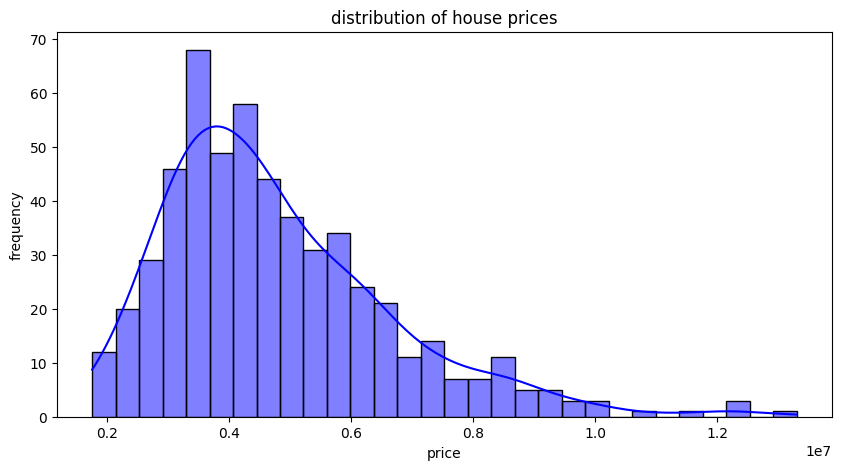

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=30, kde=True, color='blue')
plt.title('distribution of house prices')
plt.xlabel('price')
plt.ylabel('frequency')
plt.show()

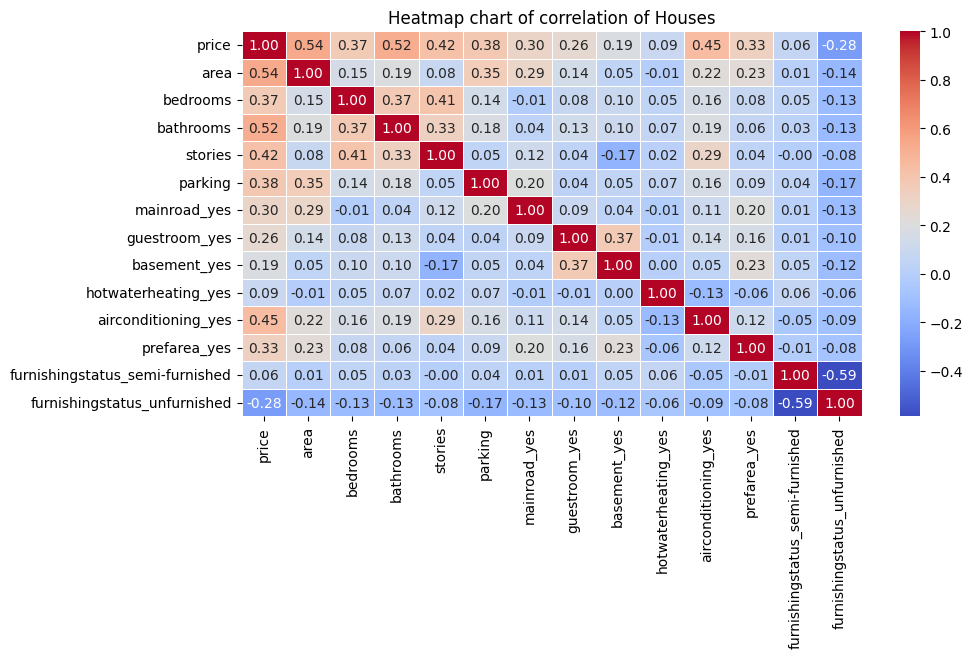

In [46]:
plt.figure(figsize=(10, 5))
correlation_mat = df.corr()
sns.heatmap(correlation_mat, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap chart of correlation of Houses')
plt.show()

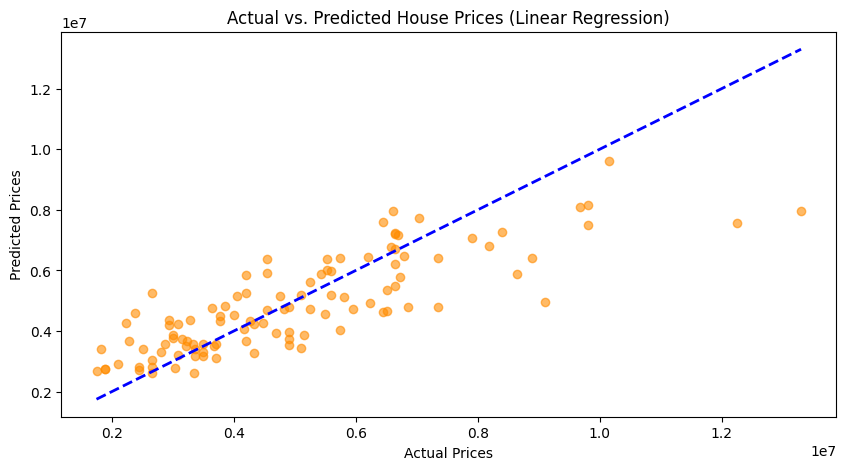

In [47]:
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_Pred_Lr, alpha=0.6, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', lw=2)
plt.title('Actual vs. Predicted House Prices (Linear Regression)')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.show()

According to the heatmap the house price was mostly influenced by area then followed by no of bathrooms.
The Linear Regression model was moderately accurate, it's accuracy is about 65.3%(R² = 0.65). In practical terms, when the model guesses a house's price, it is typically off by an average of about 970,000 units (MAE) from the actual selling price.
The biggest surprise was that the linear regression model actually outperformed the random forest regression model. Because the dataset is very small and a random-forest catagory need to feed from vast dataset to get better accuracy so linear regression outperformed here.
As for a recommendation for the real estate business that we should more focus on making the area of houses and no of bathroom big as per recommendation and adjustable for which can generate high revenue for the investors.
